# Top-1,000 follower geography: city bubbles and leading-band photos

## tl;dr

- **London leads by a large margin:** its mapped bands sum to **493 million** Spotify followers, **7.9×** Manchester's total.
- The top 10 FUAs contain **89.1% of followers allocated to mapped cities**, or **82.3% of the full selected top-1,000 follower denominator**.
- Map 1 uses bubble **area** in direct proportion to each city's combined follower total.
- Map 2 keeps exactly the same cities, positions and area scale. Its photo is only the **largest-followed selected band** in that city: Coldplay is 13.1% of London's total, while Muse is 99.7% of Exeter's and The Cure is 100% of Crawley's.
- Map 3 shows the **follower output quotient**, or "punching above weight" multiplier. Crawley reaches **3.56×**, while Leeds is **0.19×**.

Map 1 shows absolute follower reach, Map 3 shows reach relative to population, and the photo version identifies one band rather than depicting the whole scene.

## 01. Context and methods

This experiment maps the follower output already defined in the top-1,000 share analysis. For FUA (i), the metric is

$$
F_i = \sum_{b \in i} \text{Spotify followers}_b.
$$

Only strict and reviewed-extended FUA assignments are allocated. Unresolved or excluded bands stay in the selected-catalogue denominator and are not redistributed. A "combined follower" is a summed account-to-band follow relationship, **not a unique person**: one Spotify user may follow several bands.

Bubble area is (A_i = F_i / 100{,}000) points², so a city with twice the follower total gets twice the bubble area. The centre pin is the named city's Wikidata coordinate and stands in for its whole OECD/EU Functional Urban Area; it is not an FUA centroid or boundary.

The photo in Map 2 is selected deterministically: the mapped band with the largest Spotify follower count in that FUA. It is an identity cue, not a weighted collage and not evidence that one band caused the city's total.

Map 3 uses the follower output quotient:

$$
Q_i = \frac{F_i / F_{\text{selected UK top 1,000}}}{P_i / P_{\text{all 83 UK FUAs}}}.
$$

At **1×**, follower share equals population share. Above 1× is punching above population weight; below 1× is under the proportional benchmark. Bubble area is proportional to `Q_i`; filled circles are at or above 1× and open circles are below it. The displayed set remains the same top ten chosen by raw combined followers.

### Frozen supporting assets

- UK outline: Natural Earth 1:50m Admin 0, public domain.
- City coordinates: Wikidata `P625`, CC0.
- Band photos: local Wikimedia Commons thumbnails; the per-file creator, page and licence are listed after the maps.


## 02. Data

In [1]:
from pathlib import Path
import hashlib
import json
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "data/processed/popularity_first_top1000_20260718T204522Z_bands.csv").exists()
    ),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Could not locate the uk-music-cities repository root")

SRC_DIR = ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from python_uk_bands.follower_maps import (
    load_geojson,
    plot_city_follower_bubbles,
    plot_city_follower_output_quotient,
    plot_city_follower_photo_bubbles,
    prepare_top_city_map_data,
)
from python_uk_bands.output_share import build_output_share_metrics

SNAPSHOT_ID = "20260718T204522Z"
TOP_CITY_COUNT = 10
BANDS_PATH = ROOT / "data/processed/popularity_first_top1000_20260718T204522Z_bands.csv"
MAPPING_PATH = ROOT / "data/interim/popularity_first_top1000_20260718T204522Z_fua_mapping_audit.csv"
POPULATION_PATH = ROOT / "data/processed/uk_fua_population_2024_20260830T221015Z.csv"
COORDINATE_PATH = ROOT / "reference/top1000_fua_map_coordinates_20260723.csv"
PHOTO_MANIFEST_PATH = ROOT / "reference/top1000_city_band_photo_manifest_20260723.csv"
CAPTURE_METADATA_PATH = ROOT / "reference/top1000_follower_map_asset_capture_20260723.json"
GEOGRAPHY_PATH = ROOT / "data/raw/geography/natural_earth_50m_united_kingdom_20260723.geojson"
ARTIFACT_DIR = ROOT / "artifacts/experiments/top1000_follower_maps/20260718T204522Z"

bands = pd.read_csv(BANDS_PATH, keep_default_na=False)
mapping_audit = pd.read_csv(MAPPING_PATH, keep_default_na=False)
population = pd.read_csv(POPULATION_PATH, keep_default_na=False)
coordinates = pd.read_csv(COORDINATE_PATH, keep_default_na=False)
photo_manifest = pd.read_csv(PHOTO_MANIFEST_PATH, keep_default_na=False)
with CAPTURE_METADATA_PATH.open(encoding="utf-8") as handle:
    capture_metadata = json.load(handle)

shares, coverage = build_output_share_metrics(
    bands,
    mapping_audit,
    population,
    included_tiers={"strict", "reviewed_extended"},
)
map_data = prepare_top_city_map_data(
    shares,
    coordinates,
    photo_manifest,
    top_city_count=TOP_CITY_COUNT,
)
geography = load_geojson(GEOGRAPHY_PATH)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

def file_sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

assert len(bands) == bands["returned_spotify_id"].nunique() == 1000
assert coverage["mapped_bands"] == int(shares["band_count"].sum()) == 666
assert coverage["population_fuas"] == len(shares) == 83
assert map_data["study_city_label"].tolist() == ['London', 'Manchester', 'Sheffield', 'Liverpool', 'Birmingham', 'Oxford', 'Glasgow', 'Leeds', 'Exeter', 'Crawley']
assert file_sha256(GEOGRAPHY_PATH) == capture_metadata["natural_earth"]["sha256"]
for photo in map_data.itertuples(index=False):
    assert file_sha256(ROOT / photo.local_path) == photo.image_sha256

MAP_DATA_PATH = ARTIFACT_DIR / "top_city_follower_map_data.csv"
map_data.to_csv(MAP_DATA_PATH, index=False)

coverage_table = pd.DataFrame(
    [
        {"Measure": "Selected bands", "Value": f"{coverage['selected_bands']:,}"},
        {"Measure": "Mapped bands", "Value": f"{coverage['mapped_bands']:,} ({coverage['mapped_band_share']:.1%})"},
        {"Measure": "Mapped follower coverage", "Value": f"{coverage['mapped_follower_share']:.1%}"},
        {"Measure": "Population universe", "Value": f"{coverage['population_fuas']} FUAs"},
        {"Measure": "Mapped FUAs", "Value": f"{coverage['mapped_fuas']}"},
        {"Measure": "Displayed FUAs", "Value": f"{TOP_CITY_COUNT}"},
    ]
)
display(coverage_table.style.hide(axis="index"))
display(Markdown(f"Saved the joined map frame to `{MAP_DATA_PATH.relative_to(ROOT)}`."))


Measure,Value
Selected bands,"1,000"
Mapped bands,666 (66.6%)
Mapped follower coverage,92.6%
Population universe,83 FUAs
Mapped FUAs,59
Displayed FUAs,10


Saved the joined map frame to `artifacts/experiments/top1000_follower_maps/20260718T204522Z/top_city_follower_map_data.csv`.

### The ten displayed cities

The ranking is based on the sum across all mapped selected bands, not on the pictured band's followers alone.

In [2]:
ranking = map_data[
    [
        "rank_by_followers",
        "study_city_label",
        "followers_total",
        "band_count",
        "follower_output_quotient",
        "largest_band_by_followers",
        "largest_band_follower_share",
    ]
].rename(
    columns={
        "rank_by_followers": "Rank",
        "study_city_label": "FUA",
        "followers_total": "Combined followers",
        "band_count": "Mapped bands",
        "follower_output_quotient": "Follower output quotient",
        "largest_band_by_followers": "Photo / largest band",
        "largest_band_follower_share": "Largest-band share",
    }
)
display(
    ranking.style.hide(axis="index").format(
        {
            "Combined followers": "{:,.0f}",
            "Follower output quotient": "{:.2f}×",
            "Largest-band share": "{:.1%}",
        }
    )
)


Rank,FUA,Combined followers,Mapped bands,Follower output quotient,Photo / largest band,Largest-band share
1,London,"504,360,128",309,2.31×,Coldplay,12.8%
2,Manchester,"62,312,293",54,1.01×,Oasis,22.4%
3,Sheffield,"55,959,036",22,2.67×,Arctic Monkeys,62.6%
4,Liverpool,"43,972,954",37,1.60×,The Beatles,73.6%
5,Birmingham,"34,322,827",27,0.61×,Black Sabbath,31.2%
6,Oxford,"24,182,492",8,2.32×,Radiohead,68.7%
7,Glasgow,"15,241,864",29,0.47×,Franz Ferdinand,21.1%
8,Leeds,"10,858,042",26,0.21×,alt-J,32.2%
9,Exeter,"8,949,427",1,1.00×,Muse,100.0%
10,Crawley,"7,492,117",1,3.51×,The Cure,100.0%


## 03. Results

### 03.01 Map 1: combined follower totals

/Users/dpradilla/dev/uk-music-cities/src/python_uk_bands/follower_maps.py:357: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


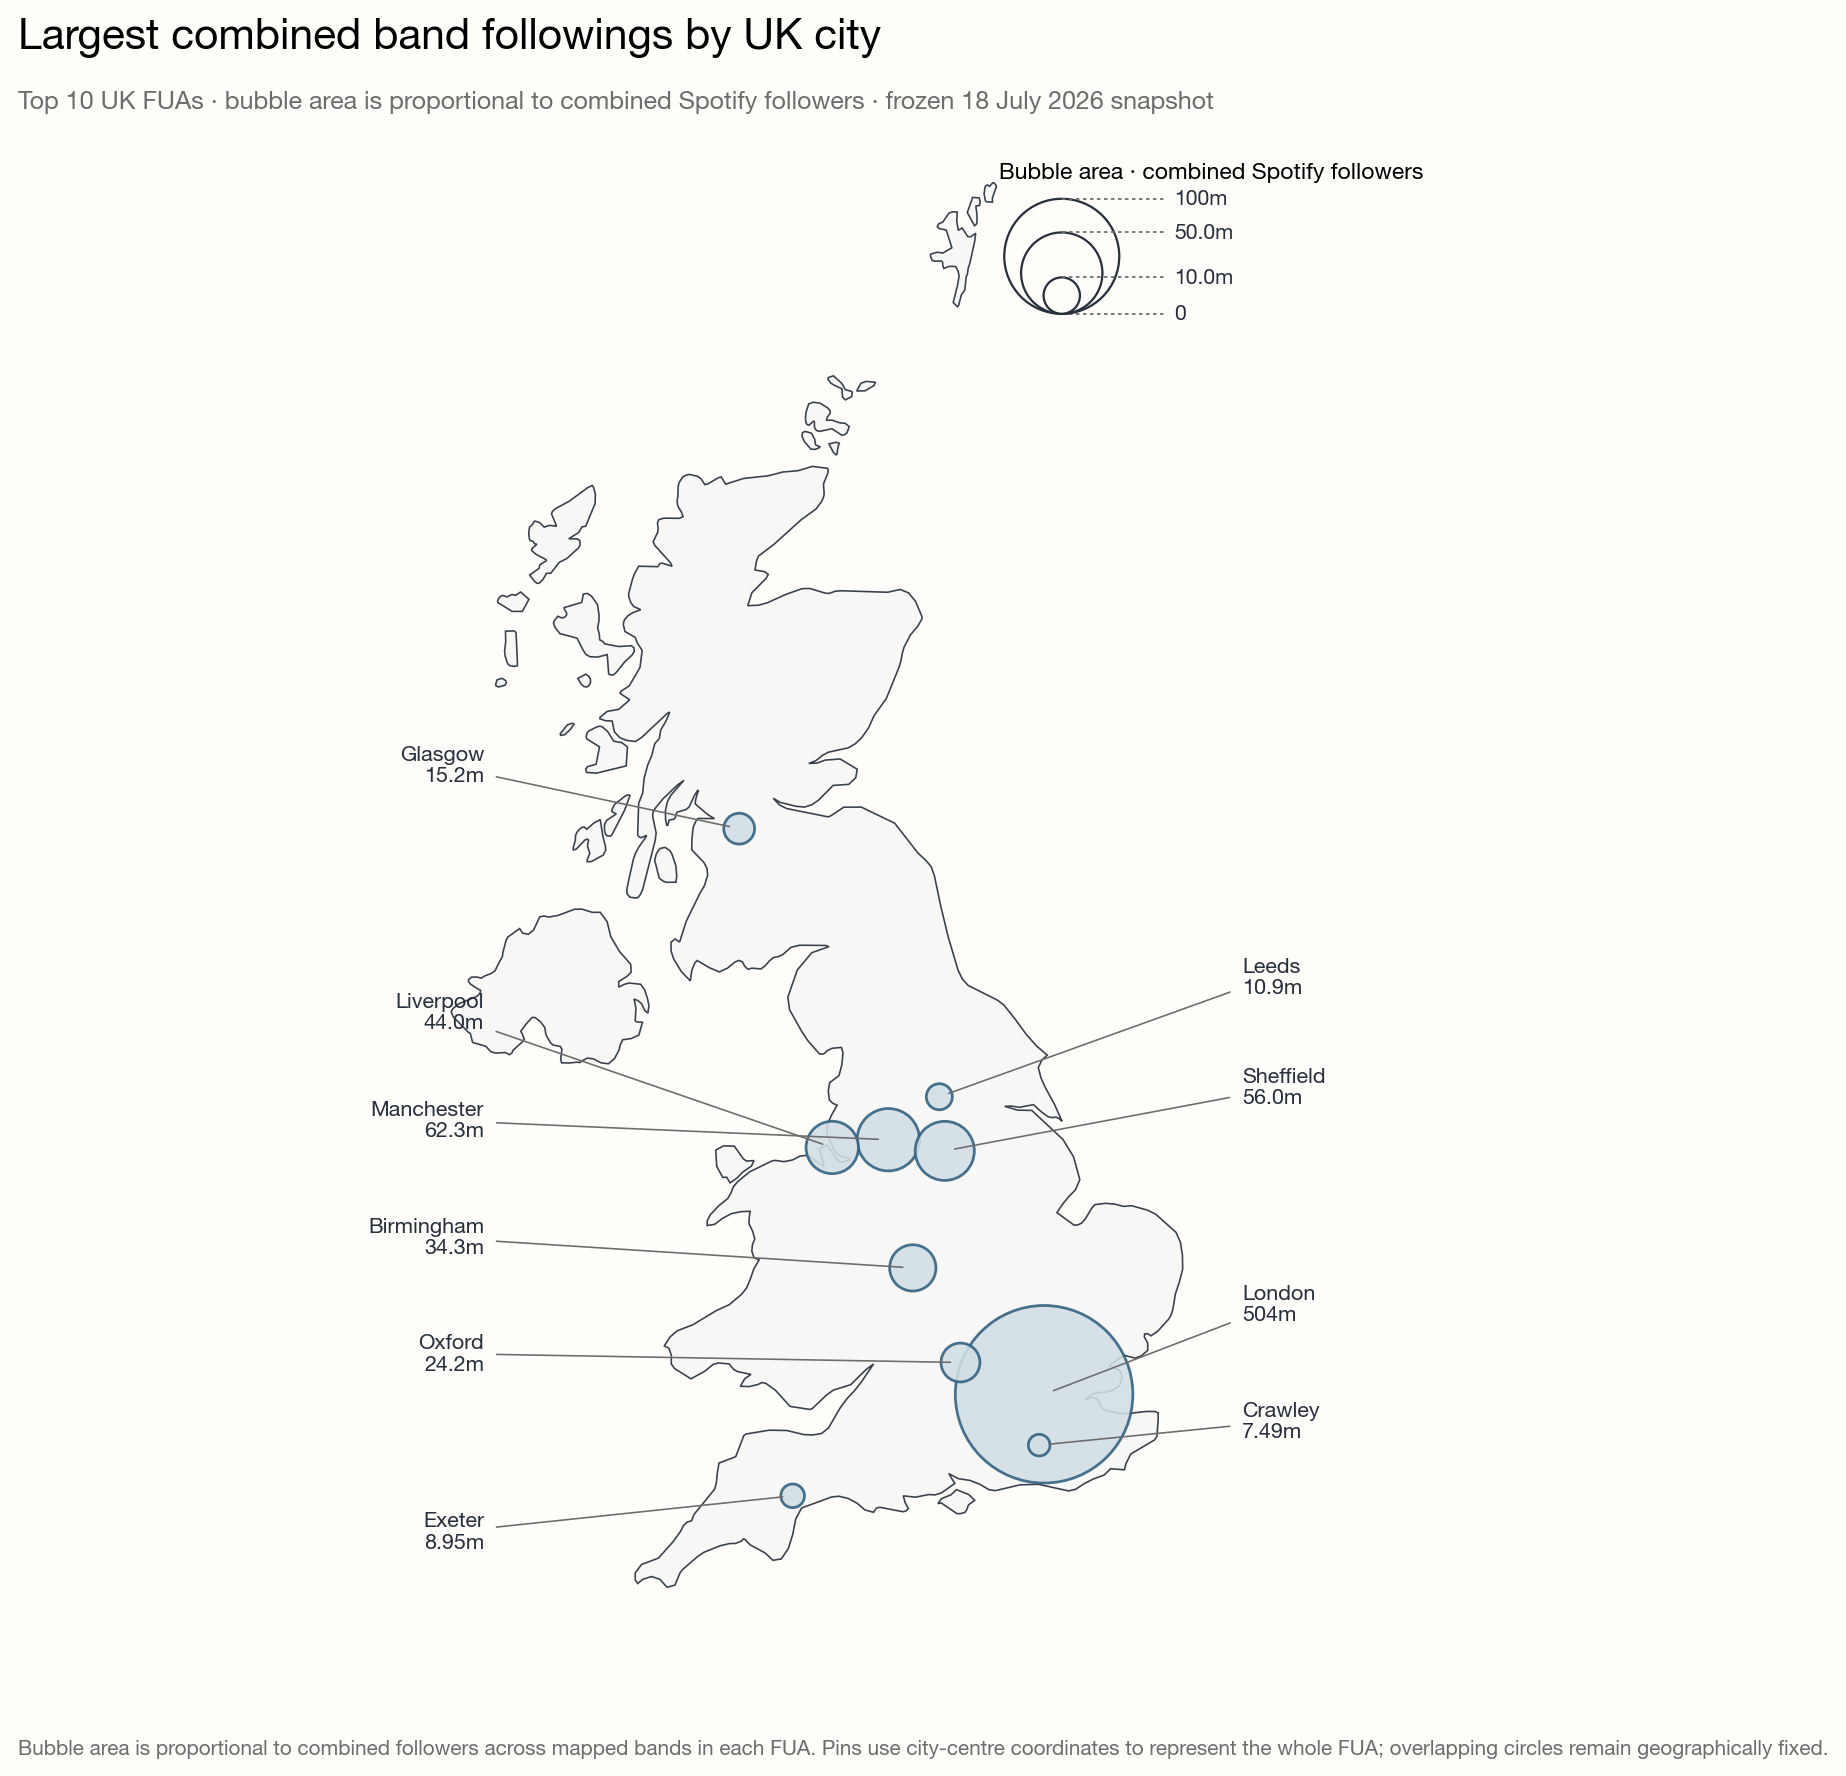

Exported to `artifacts/experiments/top1000_follower_maps/20260718T204522Z/chart_01_top_city_follower_bubbles.png`.

In [3]:
FOLLOWER_MAP_PATH = ARTIFACT_DIR / "chart_01_top_city_follower_bubbles.png"
plot_city_follower_bubbles(
    map_data,
    geography,
    snapshot_date="18 July 2026",
    output_path=FOLLOWER_MAP_PATH,
)
display(Image(filename=str(FOLLOWER_MAP_PATH)))
display(Markdown(f"Exported to `{FOLLOWER_MAP_PATH.relative_to(ROOT)}`."))


London's **493m** combined follower total dominates the area encoding. Manchester (**62.1m**), Sheffield and Liverpool form the next tier. The top 10 together contain **89.1% of all followers that could be allocated to an FUA**.

This is a map of the global follower reach attached to bands from each city, not a map of where those followers live.

### 03.02 Map 2: same totals, filled with each city's largest band

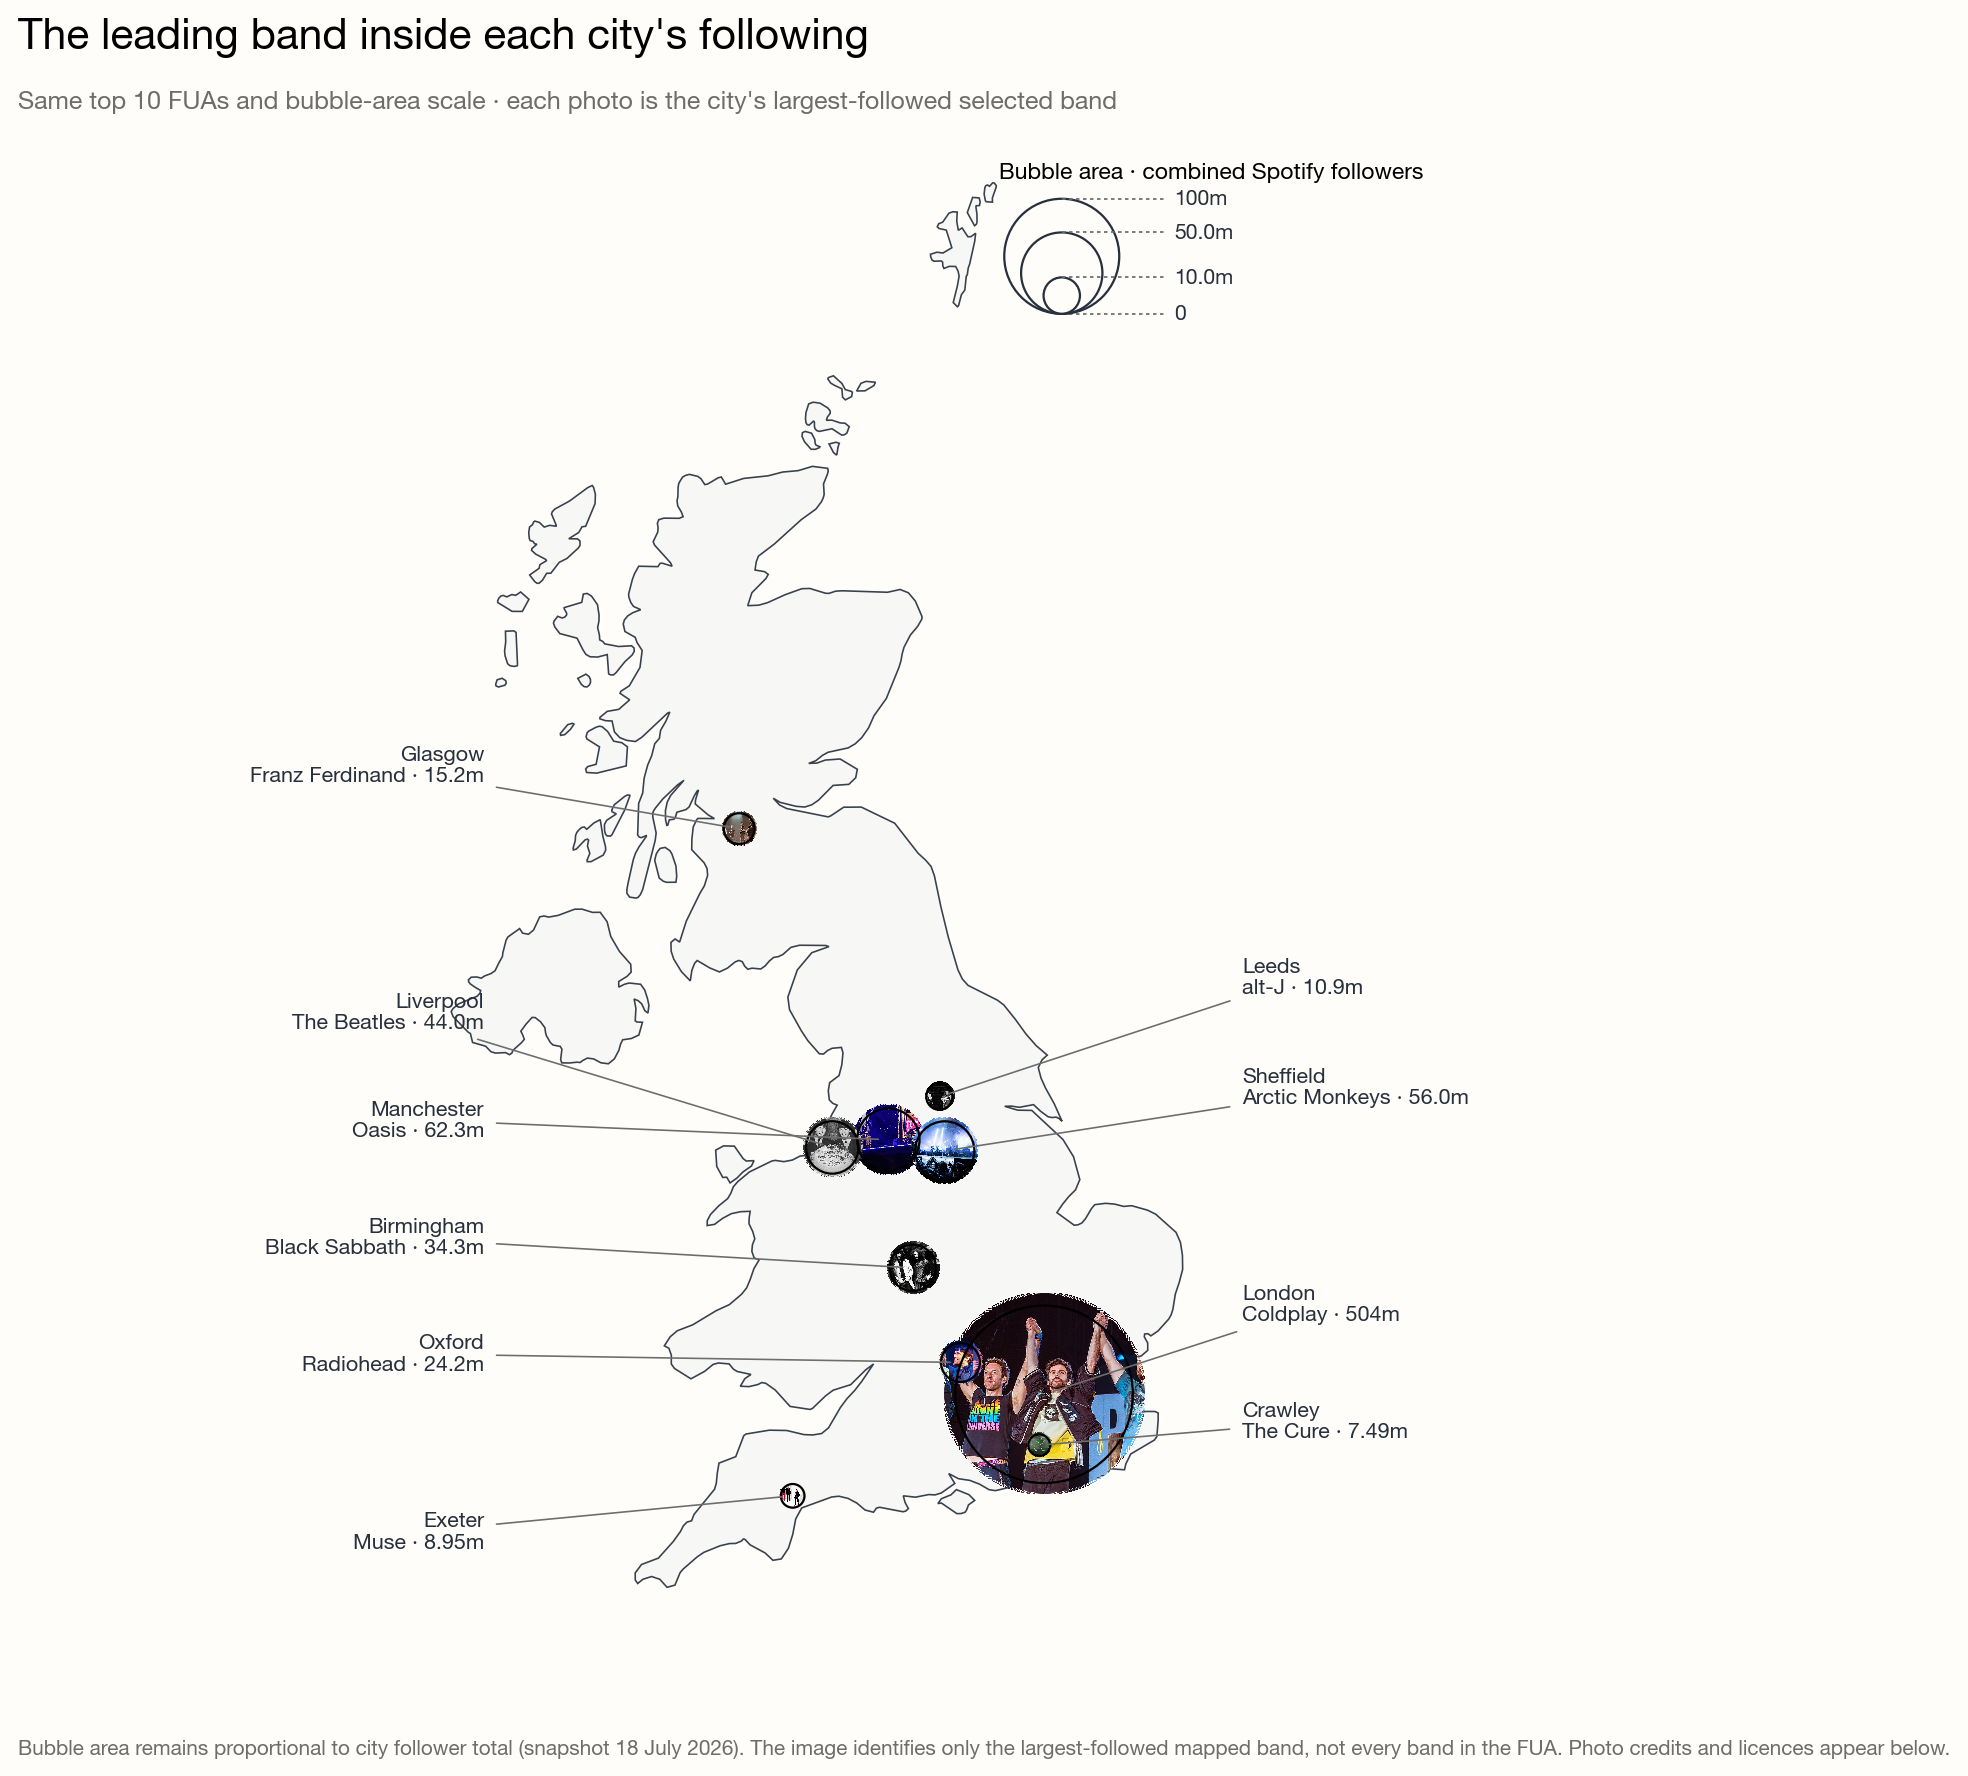

Exported to `artifacts/experiments/top1000_follower_maps/20260718T204522Z/chart_02_top_city_follower_photo_bubbles.png`.

In [4]:
PHOTO_MAP_PATH = ARTIFACT_DIR / "chart_02_top_city_follower_photo_bubbles.png"
plot_city_follower_photo_bubbles(
    map_data,
    geography,
    project_root=ROOT,
    snapshot_date="18 July 2026",
    output_path=PHOTO_MAP_PATH,
)
display(Image(filename=str(PHOTO_MAP_PATH)))
display(Markdown(f"Exported to `{PHOTO_MAP_PATH.relative_to(ROOT)}`."))


The photo layer is most representative where one band supplies nearly all of the city total: Crawley (**The Cure, 100%**) and Exeter (**Muse, 99.7%**). It is much less representative of a broad catalogue such as London, where Coldplay supplies only **13.1%** of the combined total.

That difference is why the plain-circle version remains the primary analytical chart.

### 03.03 Map 3: follower output relative to population weight

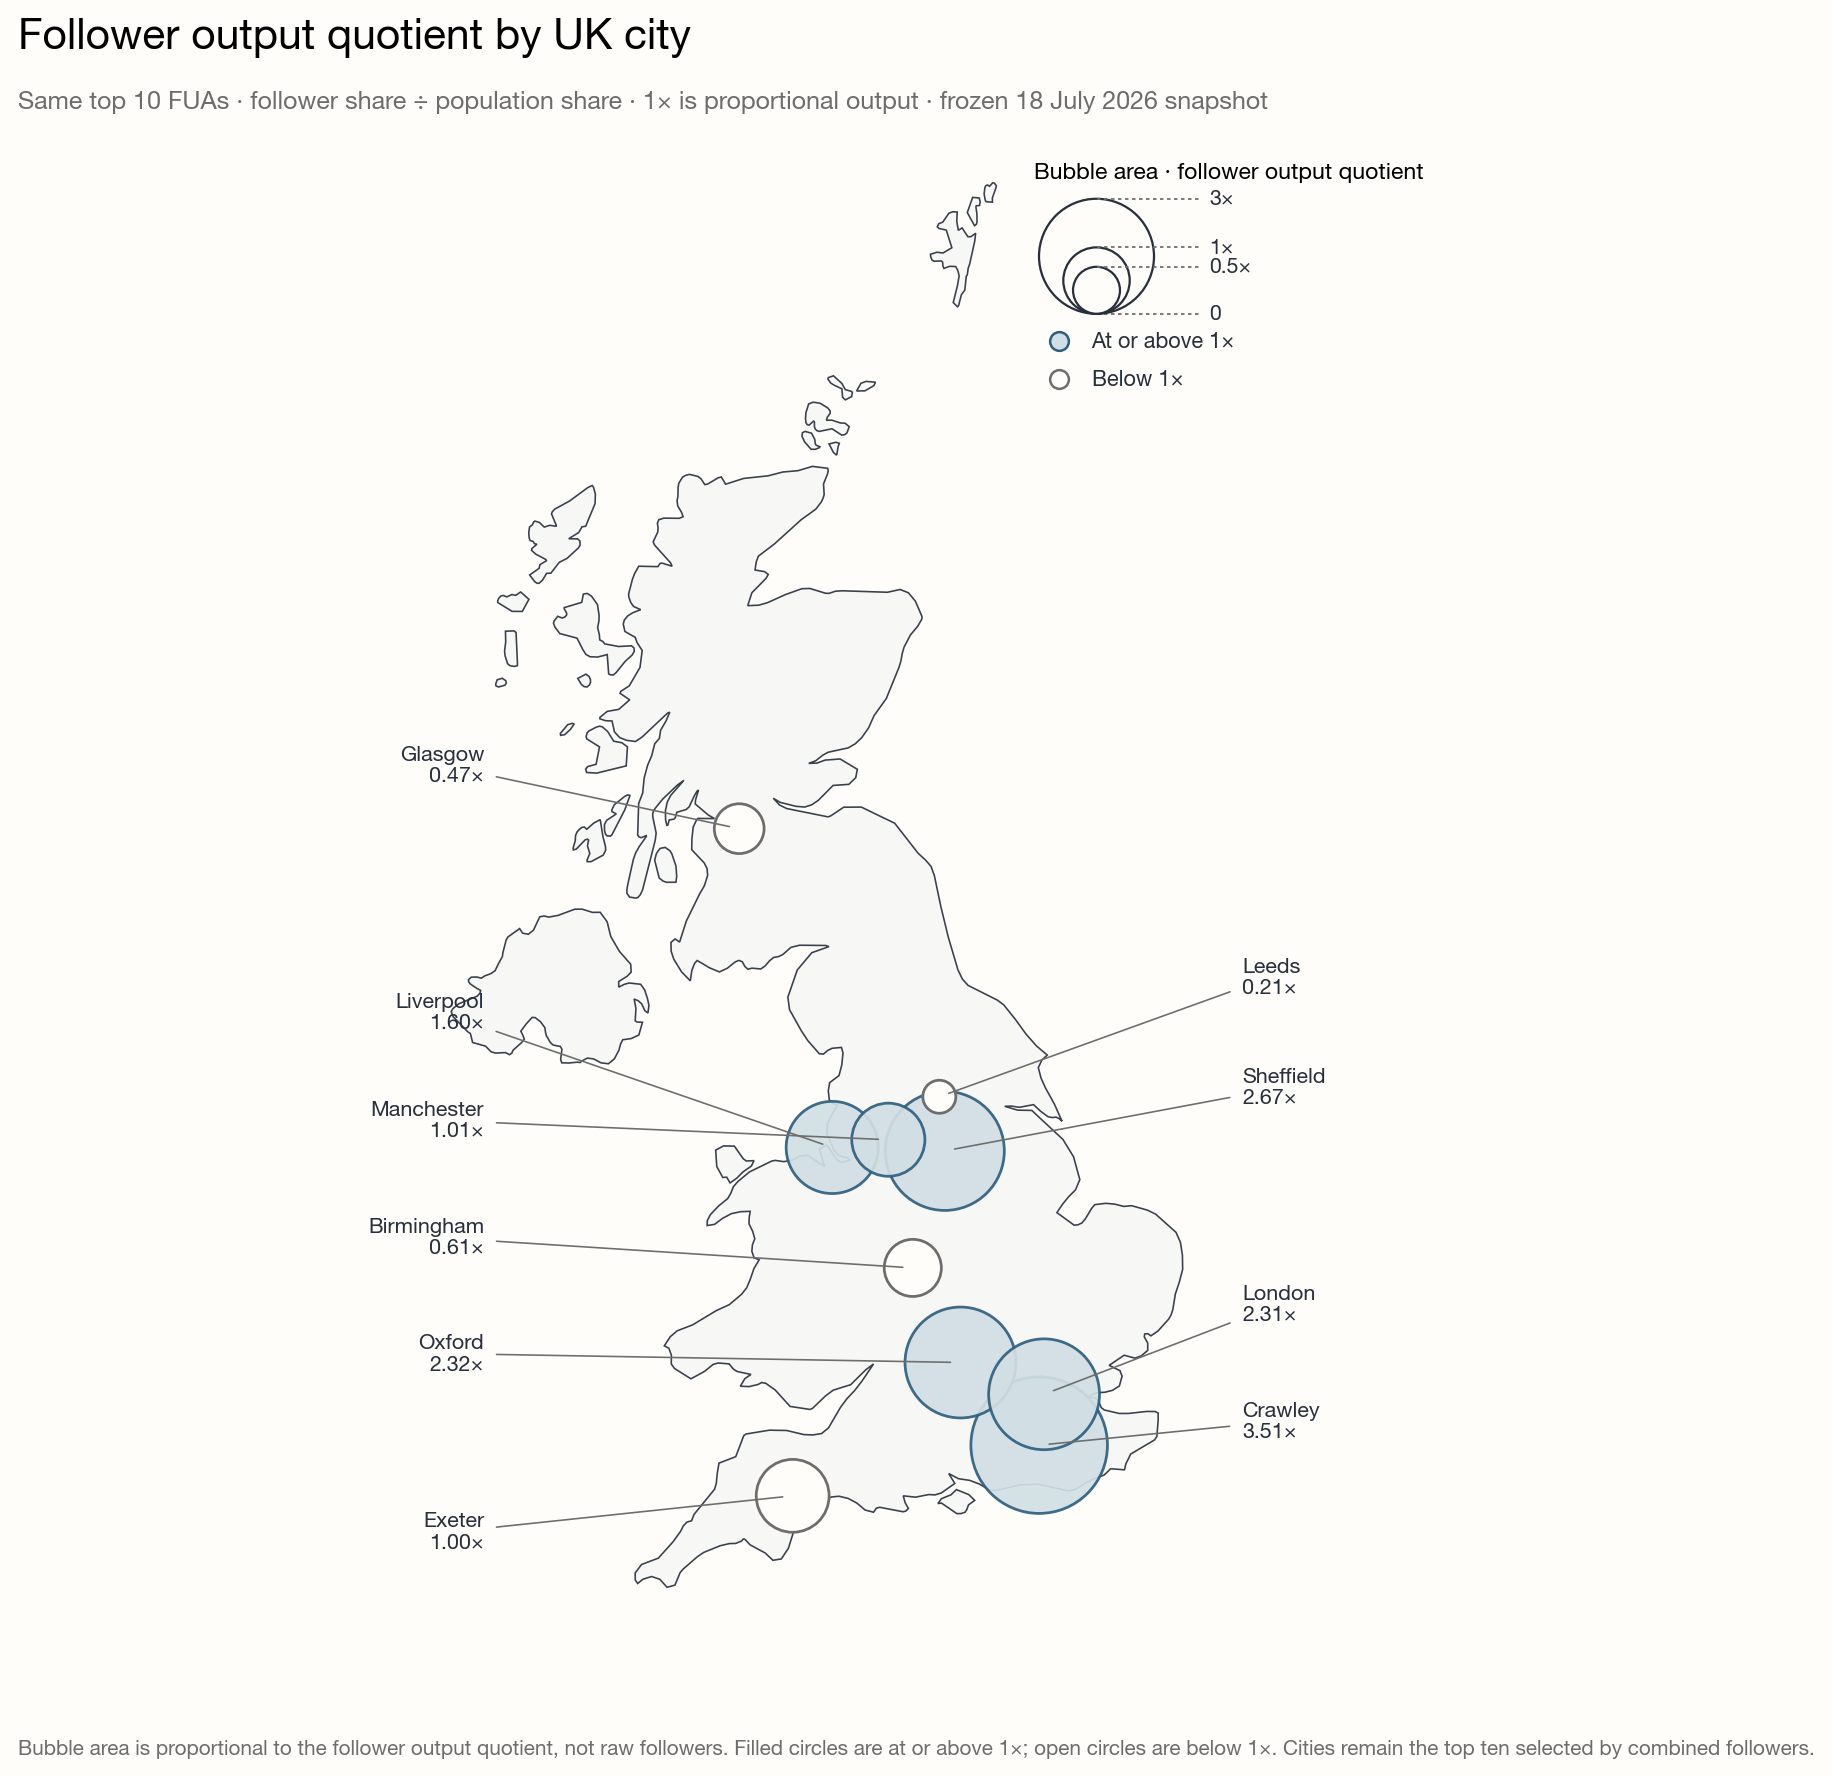

Exported to `artifacts/experiments/top1000_follower_maps/20260718T204522Z/chart_03_follower_output_quotient_map.png`.

In [5]:
OUTPUT_QUOTIENT_MAP_PATH = ARTIFACT_DIR / "chart_03_follower_output_quotient_map.png"
plot_city_follower_output_quotient(
    map_data,
    geography,
    snapshot_date="18 July 2026",
    output_path=OUTPUT_QUOTIENT_MAP_PATH,
)
display(Image(filename=str(OUTPUT_QUOTIENT_MAP_PATH)))
display(Markdown(f"Exported to `{OUTPUT_QUOTIENT_MAP_PATH.relative_to(ROOT)}`."))


This is the **punching-above-weight map**. Among the same ten high-following FUAs, Crawley leads at **3.56×**, followed by Sheffield at **2.70×**. London is also well above proportional at **2.29×**. Leeds is the clearest below-benchmark case at **0.19×**.

The quotient changes the question: Map 1 asks "where is follower output largest?", while Map 3 asks "where is follower output largest relative to population share?"

## 04. Photo credits and licences

In [6]:
for photo in map_data.itertuples(index=False):
    creator = photo.artist or photo.credit or "See source page"
    license_part = photo.license_short_name or "See source page"
    if photo.license_url:
        license_part = f"[{license_part}]({photo.license_url})"
    display(
        Markdown(
            f"- **{photo.study_city_label} — {photo.band_name}:** "
            f"[{creator}]({photo.commons_page_url}); {license_part}."
        )
    )

display(
    Markdown(
        "**Base geography:** [Natural Earth 1:50m Admin 0]"
        f"({capture_metadata['natural_earth']['source_page_url']}), public domain. "
        "**Coordinates:** Wikidata P625, CC0; per-city source URLs are in the joined map CSV."
    )
)


- **London — Coldplay:** [Raph_PH](https://commons.wikimedia.org/wiki/File:ColdplayWembley120925_(cropped).jpg); [CC BY 4.0](https://creativecommons.org/licenses/by/4.0).

- **Manchester — Oasis:** [Raph_PH](https://commons.wikimedia.org/wiki/File:Oasis_-_Wembley_Stadium_-_Saturday_27th_September_2025.jpg); [CC BY 4.0](https://creativecommons.org/licenses/by/4.0).

- **Sheffield — Arctic Monkeys:** [Bill Ebbesen](https://commons.wikimedia.org/wiki/File:Arctic_Monkeys_-_Orange_Stage_-_Roskilde_Festival_2014.jpg); [CC BY 3.0](https://creativecommons.org/licenses/by/3.0).

- **Liverpool — The Beatles:** [Bo Trenter](https://commons.wikimedia.org/wiki/File:Beatles_Trenter_1963.jpg); Public domain.

- **Birmingham — Black Sabbath:** [Warner Bros. Records](https://commons.wikimedia.org/wiki/File:Black_Sabbath_(1970).png); Public domain.

...

- **Glasgow — Franz Ferdinand:** [Erin Mc](https://commons.wikimedia.org/wiki/File:Franz_Ferdinand.jpg); [CC BY 2.0](https://creativecommons.org/licenses/by/2.0).

- **Leeds — alt-J:** [Drew de F Fawkes from Guildford, United Kingdom](https://commons.wikimedia.org/wiki/File:Alt-J,_Pryzm,_Kingston_(52132709047).jpg); [CC BY 2.0](https://creativecommons.org/licenses/by/2.0).

- **Exeter — Muse:** [Warner Music Sweden](https://commons.wikimedia.org/wiki/File:Muse_2006_003.jpg); [CC BY 3.0](https://creativecommons.org/licenses/by/3.0).

- **Crawley — The Cure:** [momento mori from Kuala Lumpur, Malaysia](https://commons.wikimedia.org/wiki/File:The_Cure_Live_in_Singapore_2-_1st_August_2007.jpg); [CC BY 2.0](https://creativecommons.org/licenses/by/2.0).

**Base geography:** [Natural Earth 1:50m Admin 0](https://www.naturalearthdata.com/downloads/50m-cultural-vectors/50m-admin-0-countries-2/), public domain. **Coordinates:** Wikidata P625, CC0; per-city source URLs are in the joined map CSV.

## 05. Limitations

- The Spotify capture is a frozen **18 July 2026** snapshot. Follower counts change.
- Only **666 of 1,000 selected bands** have an included FUA assignment. They cover **92.6%** of selected followers, but origin-missing bands remain unallocated.
- Summed followers are not unique audience. A person can follow multiple bands, and the data do not reveal follower residence.
- City-centre points represent FUAs. They do not show FUA boundaries, intra-FUA origins or movement between cities.
- Historical bands are compared with current place coordinates and 2024 FUA definitions.
- A single photo can overstate one band's representativeness, particularly in cities with broad catalogues.
- The quotient map compares only the same top ten cities selected by raw follower total; it is not a ranking of every UK FUA by quotient.

## 06. Conclusion

Use **Map 1** to compare city-level follower output and **Map 3** for the population-relative "punching above weight" comparison. **Map 2** helps identify the leading band, but it needs the subtitle and attribution table so the portrait is not mistaken for the whole scene.